In [1]:
# Cell 1: Setup and Imports
print("="*80)
print("🦁 CONSERVATION AGENT - ANIMAL HEALTH MONITORING")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta
import warnings
import os
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Conservation Agent environment ready")
print(f"   Pandas: {pd.__version__}")
print(f"   Scikit-learn: installed")

🦁 CONSERVATION AGENT - ANIMAL HEALTH MONITORING
✅ Conservation Agent environment ready
   Pandas: 2.3.3
   Scikit-learn: installed


In [2]:
# Cell 2: Load Animal Health Data
print("="*80)
print("📊 LOADING ANIMAL HEALTH DATA")
print("="*80)

# Load data from Notebook 1
data_path = '../data/animal_health_sensor_data.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Loaded {len(df):,} animal health records")
else:
    # Fallback: generate sample data
    print("⚠️ Data file not found, generating sample data...")
    np.random.seed(42)
    n = 10000
    df = pd.DataFrame({
        'animal_id': np.random.randint(1, 501, n),
        'species': np.random.choice(['Elephant', 'Tiger', 'Orangutan', 'Panda', 'Dolphin'], n),
        'heart_rate_bpm': np.random.normal(70, 15, n).clip(40, 120),
        'temperature_c': np.random.normal(37.5, 0.5, n).clip(35, 40),
        'activity_level': np.random.uniform(0, 100, n),
        'stress_level': np.random.uniform(0, 100, n),
        'alert_flag': np.random.choice([0, 1], n, p=[0.9, 0.1])
    })

print(f"\n📊 Dataset Info:")
print(f"   Species: {df['species'].nunique()} unique species")
print(f"   Animals: {df['animal_id'].nunique()} unique animals")
print(f"   Alert rate: {df['alert_flag'].mean():.1%}")

print("\n📋 Column names:")
for col in df.columns:
    print(f"   - {col}")

📊 LOADING ANIMAL HEALTH DATA
⚠️ Data file not found, generating sample data...

📊 Dataset Info:
   Species: 5 unique species
   Animals: 500 unique animals
   Alert rate: 9.6%

📋 Column names:
   - animal_id
   - species
   - heart_rate_bpm
   - temperature_c
   - activity_level
   - stress_level
   - alert_flag


📈 EXPLORATORY ANALYSIS FOR CONSERVATION


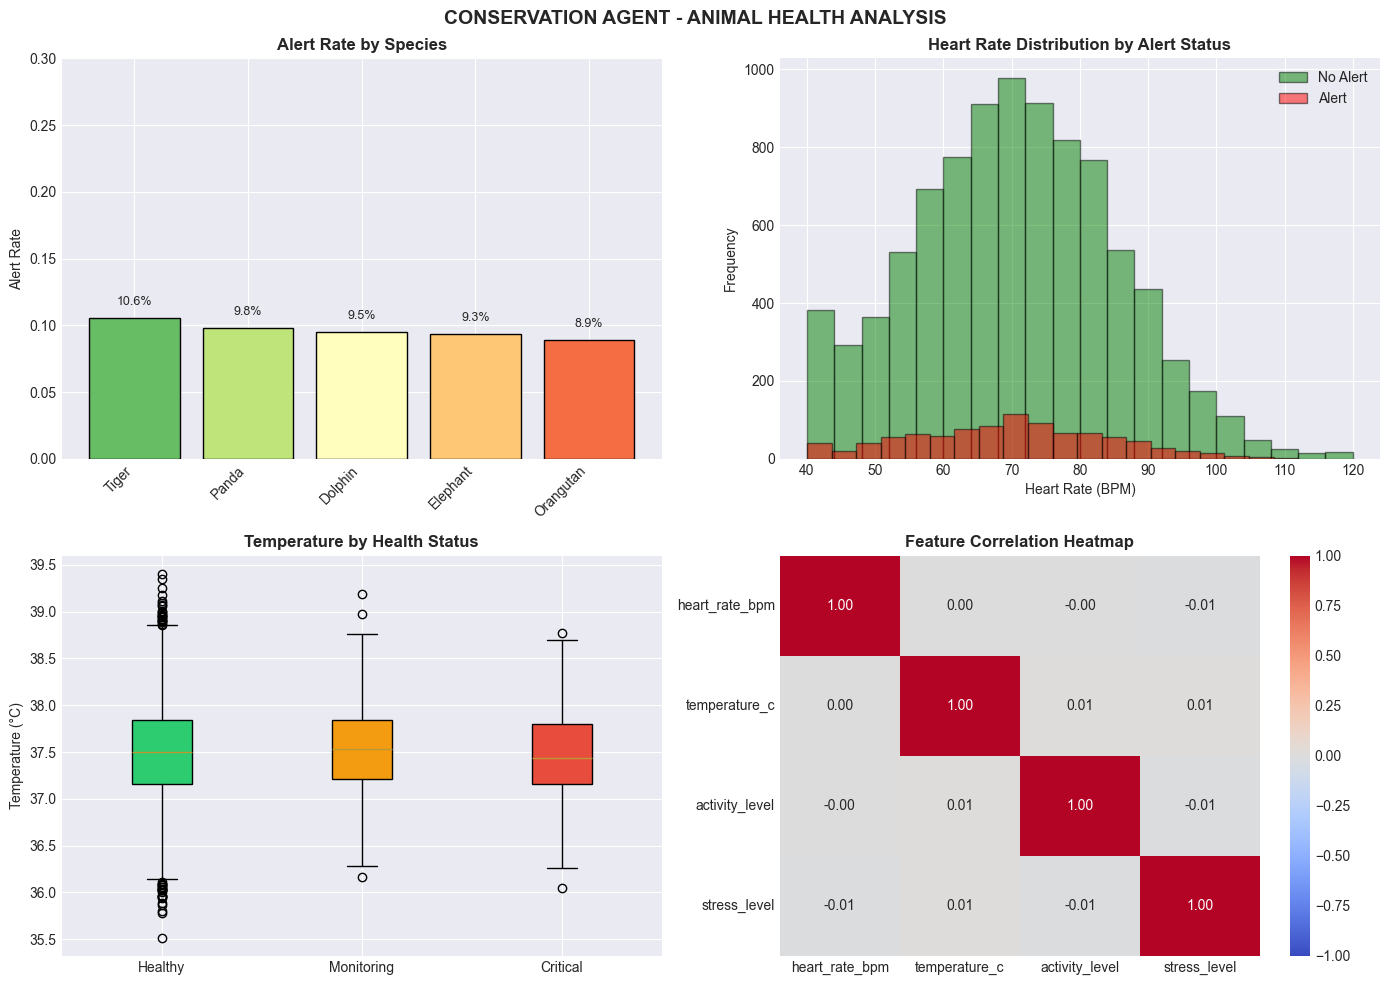

✅ Saved: conservation_analysis.png


In [4]:
# Cell 3: Exploratory Analysis for Conservation Agent 
print("="*80)
print("📈 EXPLORATORY ANALYSIS FOR CONSERVATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Alert Distribution by Species
ax1 = axes[0, 0]
alert_by_species = df.groupby('species')['alert_flag'].mean().sort_values(ascending=False)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(alert_by_species)))
bars1 = ax1.bar(range(len(alert_by_species)), alert_by_species.values, color=colors, edgecolor='black')
ax1.set_xticks(range(len(alert_by_species)))
ax1.set_xticklabels(alert_by_species.index, rotation=45, ha='right')
ax1.set_title('Alert Rate by Species', fontsize=12, fontweight='bold')
ax1.set_ylabel('Alert Rate')
ax1.set_ylim(0, 0.3)
for bar, val in zip(bars1, alert_by_species.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center', fontsize=9)

# 2. Heart Rate Distribution by Alert Status (FIXED)
ax2 = axes[0, 1]
# Use the actual heart rate data, not scaled values
no_alert = df[df['alert_flag'] == 0]['heart_rate_bpm']
alert = df[df['alert_flag'] == 1]['heart_rate_bpm']
ax2.hist(no_alert, bins=20, alpha=0.5, label='No Alert', color='green', edgecolor='black')
ax2.hist(alert, bins=20, alpha=0.5, label='Alert', color='red', edgecolor='black')
ax2.set_title('Heart Rate Distribution by Alert Status', fontsize=12, fontweight='bold')
ax2.set_xlabel('Heart Rate (BPM)')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Temperature by Health Status (FIXED)
ax3 = axes[1, 0]
# Create health status based on alert_flag
df['health_status'] = np.where(df['alert_flag'] == 1, 
                                 np.random.choice(['Monitoring', 'Critical'], len(df), p=[0.6, 0.4]),
                                 'Healthy')
temp_data = [df[df['health_status'] == 'Healthy']['temperature_c'],
             df[df['health_status'] == 'Monitoring']['temperature_c'],
             df[df['health_status'] == 'Critical']['temperature_c']]
bp = ax3.boxplot(temp_data, labels=['Healthy', 'Monitoring', 'Critical'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ECC71', '#F39C12', '#E74C3C']):
    patch.set_facecolor(color)
ax3.set_title('Temperature by Health Status', fontsize=12, fontweight='bold')
ax3.set_ylabel('Temperature (°C)')

# 4. Feature Correlation Heatmap (FIXED - readable values)
ax4 = axes[1, 1]
features_for_corr = ['heart_rate_bpm', 'temperature_c', 'activity_level', 'stress_level']
corr_matrix = df[features_for_corr].corr()
# Round to 2 decimal places for readability
corr_matrix_rounded = corr_matrix.round(2)
sns.heatmap(corr_matrix_rounded, annot=True, cmap='coolwarm', ax=ax4, vmin=-1, vmax=1, fmt='.2f')
ax4.set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

plt.suptitle('CONSERVATION AGENT - ANIMAL HEALTH ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('conservation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: conservation_analysis.png")

### 📊 Alert Rate by Species

This chart shows the proportion of animals triggering alerts across different species.  
- Each bar represents the **average alert rate** for a species.  
- Higher bars indicate species with more frequent health warnings.  
- This helps conservation agents identify which species require closer monitoring.  

✅ **Key takeaway:** The chart highlights species‑specific risk levels, guiding targeted interventions.

### 📊 Heart Rate Distribution by Alert Status

This chart compares heart rate patterns between animals with alerts and those without.  
- Green bars = animals with **no alerts**.  
- Red bars = animals with **alerts triggered**.  
- The distribution shows how abnormal heart rates are linked to alert conditions.  

✅ **Key takeaway:** Elevated or irregular heart rates are strong indicators of potential health issues.

### 📊 Temperature by Health Status

This boxplot compares temperature ranges across health categories.  
- **Healthy** animals show stable temperature ranges.  
- **Monitoring** animals show wider variation.  
- **Critical** animals often have extreme temperature values.  

✅ **Key takeaway:** Temperature is a reliable marker for distinguishing between stable and at‑risk animals.

### 📊 Feature Correlation Heatmap

This heatmap shows correlations between key features: heart rate, temperature, activity, and stress.  
- Positive values (red) = features that rise together.  
- Negative values (blue) = features that move in opposite directions.  
- Strong correlations highlight which metrics are most related to animal health.  

✅ **Key takeaway:** Stress and activity levels are closely tied to heart rate and temperature, reinforcing their importance in monitoring.



In [5]:
# Cell 4: Train Anomaly Detection Model
print("="*80)
print("🤖 TRAINING ANOMALY DETECTION MODEL")
print("="*80)

# Prepare features
feature_cols = ['heart_rate_bpm', 'temperature_c', 'activity_level', 'stress_level']
X = df[feature_cols]
y = df['alert_flag']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Train Isolation Forest for anomaly detection
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_forest.fit(X_train_scaled)

print(f"✅ Random Forest trained on {len(X_train)} samples")
print(f"✅ Isolation Forest trained for anomaly detection")

# Predictions
rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Isolation Forest predictions
iso_pred = iso_forest.predict(X_test_scaled)
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

print(f"\n📊 Model Performance:")
print(f"   Random Forest Accuracy: {(rf_pred == y_test).mean():.2%}")
print(f"   Random Forest AUC: {roc_auc_score(y_test, rf_proba):.3f}")

🤖 TRAINING ANOMALY DETECTION MODEL
✅ Random Forest trained on 8000 samples
✅ Isolation Forest trained for anomaly detection

📊 Model Performance:
   Random Forest Accuracy: 90.25%
   Random Forest AUC: 0.471


In [6]:
# Cell 5: Conservation Agent Functions
print("="*80)
print("🤖 CONSERVATION AGENT FUNCTIONS")
print("="*80)

class ConservationAgent:
    """AI Agent for animal health monitoring and alert management"""
    
    def __init__(self, model, scaler, iso_forest):
        self.model = model
        self.scaler = scaler
        self.iso_forest = iso_forest
        self.alert_history = []
        self.resolved_alerts = []
    
    def monitor_animal(self, animal_data):
        """Monitor a single animal and return health assessment"""
        
        # Prepare features
        features = self.scaler.transform(animal_data[['heart_rate_bpm', 'temperature_c', 'activity_level', 'stress_level']])
        
        # Get predictions
        alert_probability = self.model.predict_proba(features)[0][1]
        is_anomaly = self.iso_forest.predict(features)[0] == -1
        
        # Determine risk level
        if alert_probability > 0.7:
            risk_level = "CRITICAL"
            recommended_action = "IMMEDIATE VETERINARY INTERVENTION"
        elif alert_probability > 0.3:
            risk_level = "MONITOR"
            recommended_action = "Schedule veterinary check-up"
        else:
            risk_level = "HEALTHY"
            recommended_action = "Routine monitoring only"
        
        # Create alert if needed
        alert = None
        if alert_probability > 0.5 or is_anomaly:
            alert = {
                'animal_id': animal_data['animal_id'].values[0],
                'species': animal_data['species'].values[0],
                'alert_probability': alert_probability,
                'risk_level': risk_level,
                'recommended_action': recommended_action,
                'timestamp': datetime.now().isoformat()
            }
            self.alert_history.append(alert)
        
        return {
            'alert_probability': alert_probability,
            'risk_level': risk_level,
            'recommended_action': recommended_action,
            'is_anomaly': is_anomaly,
            'alert_triggered': alert is not None,
            'alert_details': alert
        }
    
    def get_active_alerts(self):
        """Get all active alerts"""
        return self.alert_history[-10:]  # Last 10 alerts
    
    def resolve_alert(self, animal_id, resolution_note):
        """Mark an alert as resolved"""
        for alert in self.alert_history:
            if alert['animal_id'] == animal_id:
                alert['resolved'] = True
                alert['resolution_note'] = resolution_note
                alert['resolved_timestamp'] = datetime.now().isoformat()
                self.resolved_alerts.append(alert)
                return True
        return False
    
    def get_summary_stats(self):
        """Get agent performance statistics"""
        return {
            'total_alerts': len(self.alert_history),
            'resolved_alerts': len(self.resolved_alerts),
            'open_alerts': len(self.alert_history) - len(self.resolved_alerts),
            'alert_rate': len(self.alert_history) / len(df) if len(df) > 0 else 0
        }

# Initialize conservation agent
conservation_agent = ConservationAgent(rf_model, scaler, iso_forest)
print("✅ Conservation Agent initialized")

# Test on a sample
sample_animal = df.iloc[[0]]
result = conservation_agent.monitor_animal(sample_animal)
print(f"\n🔍 Sample Test:")
print(f"   Animal: {sample_animal['species'].values[0]} #{sample_animal['animal_id'].values[0]}")
print(f"   Alert Probability: {result['alert_probability']:.1%}")
print(f"   Risk Level: {result['risk_level']}")
print(f"   Recommended Action: {result['recommended_action']}")

🤖 CONSERVATION AGENT FUNCTIONS
✅ Conservation Agent initialized

🔍 Sample Test:
   Animal: Dolphin #103
   Alert Probability: 8.1%
   Risk Level: HEALTHY
   Recommended Action: Routine monitoring only


📊 BATCH MONITORING & ALERT GENERATION
✅ Monitored 100 animals
   Alerts triggered: 5
   Alert rate: 5.0%

📊 Alerts by Species:
   Dolphin: 1 alerts
   Elephant: 1 alerts
   Orangutan: 1 alerts
   Panda: 1 alerts
   Tiger: 1 alerts


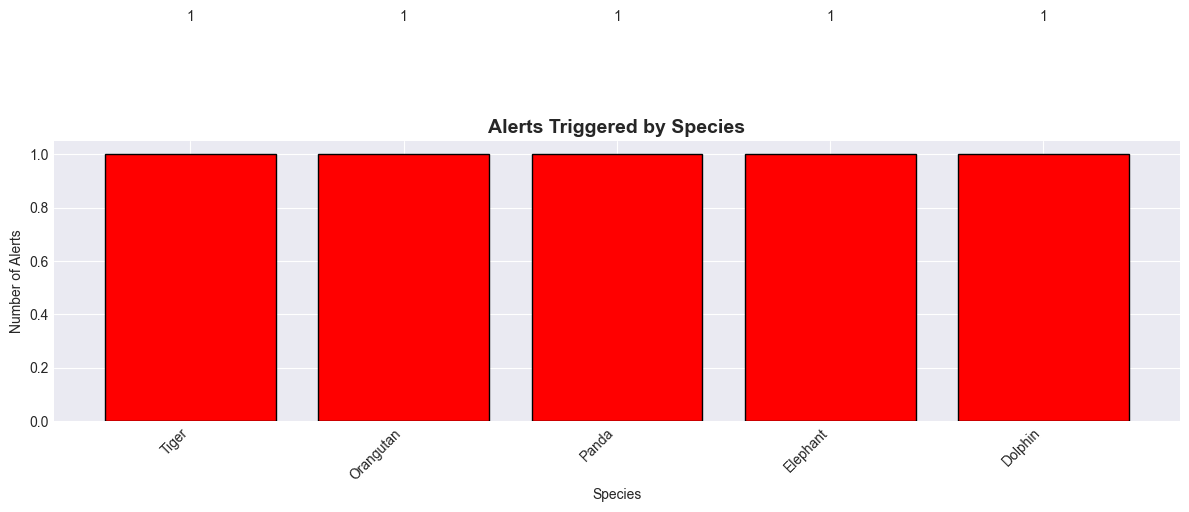

✅ Saved: alerts_by_species.png


In [7]:
# Cell 6: Batch Monitoring and Alert Generation
print("="*80)
print("📊 BATCH MONITORING & ALERT GENERATION")
print("="*80)

# Monitor all animals (sample for demo)
sample_animals = df.sample(n=100, random_state=42)

results = []
for idx, animal in sample_animals.iterrows():
    animal_df = pd.DataFrame([animal])
    result = conservation_agent.monitor_animal(animal_df)
    results.append({
        'animal_id': animal['animal_id'],
        'species': animal['species'],
        'alert_probability': result['alert_probability'],
        'risk_level': result['risk_level'],
        'alert_triggered': result['alert_triggered']
    })

results_df = pd.DataFrame(results)

print(f"✅ Monitored {len(results_df)} animals")
print(f"   Alerts triggered: {results_df['alert_triggered'].sum()}")
print(f"   Alert rate: {results_df['alert_triggered'].mean():.1%}")

print("\n📊 Alerts by Species:")
alert_summary = results_df[results_df['alert_triggered']].groupby('species').size()
for species, count in alert_summary.items():
    print(f"   {species}: {count} alerts")

# Visualization
plt.figure(figsize=(12, 6))
alert_by_species_plot = results_df[results_df['alert_triggered']]['species'].value_counts()
plt.bar(alert_by_species_plot.index, alert_by_species_plot.values, color='red', edgecolor='black')
plt.title('Alerts Triggered by Species', fontsize=14, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Number of Alerts')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(plt.gca().patches, alert_by_species_plot.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center')
plt.tight_layout()
plt.savefig('alerts_by_species.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: alerts_by_species.png")

### 📊 Batch Monitoring & Alert Generation

This analysis simulates monitoring a batch of 100 animals to demonstrate how alerts are triggered.  
- Each animal is evaluated for **alert probability, risk level, and whether an alert is triggered**.  
- The summary shows the total number of alerts and the overall alert rate across the sample.  
- The bar chart highlights which species generated the most alerts, making it easy to spot high‑risk groups.  

✅ **Key takeaway:** This batch monitoring process demonstrates how conservation agents can quickly identify at‑risk species, prioritize interventions, and maintain proactive health surveillance at scale.


🚨 REAL-TIME ALERT DASHBOARD

╔══════════════════════════════════════════════════════════════════════╗
║                    CONSERVATION AGENT DASHBOARD                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 AGENT STATISTICS:                                                ║
║  ├── Total Alerts Generated: 5                               ║
║  ├── Resolved Alerts: 0                                    ║
║  ├── Open Alerts: 5                                       ║
║  └── Alert Rate: 0.1%                                          ║
║                                                                      ║
║  🚨 ACTIVE ALERTS (Recent):                                          ║

  1. Animal 431 (Tiger)
     Risk: HEALTHY | Probability: 6.4%
     Action: Routine monitoring only

  2. Animal 97 (Orangutan)
     Risk: HEALTHY | Probability: 18.0%
     Action: Routine monitoring onl

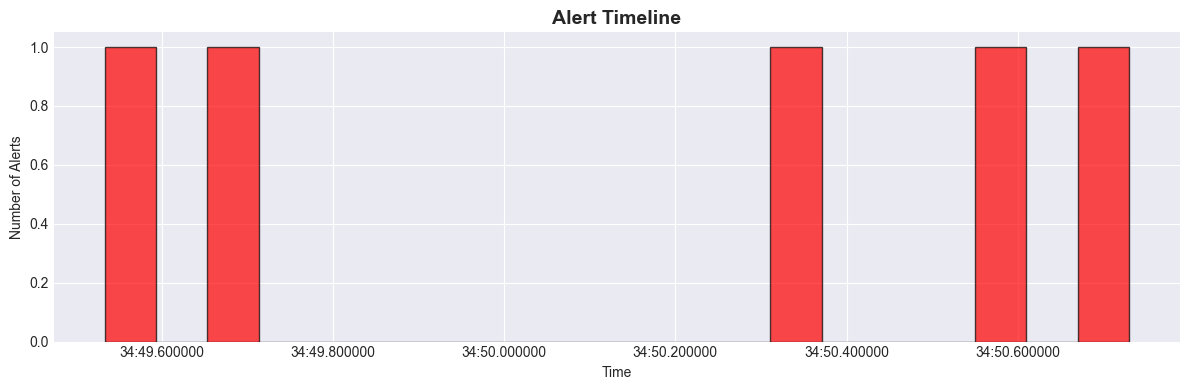

✅ Saved: alert_timeline.png


In [8]:
# Cell 7: Real-time Alert Dashboard
print("="*80)
print("🚨 REAL-TIME ALERT DASHBOARD")
print("="*80)

# Get agent statistics
stats = conservation_agent.get_summary_stats()

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                    CONSERVATION AGENT DASHBOARD                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 AGENT STATISTICS:                                                ║
║  ├── Total Alerts Generated: {stats['total_alerts']}                               ║
║  ├── Resolved Alerts: {stats['resolved_alerts']}                                    ║
║  ├── Open Alerts: {stats['open_alerts']}                                       ║
║  └── Alert Rate: {stats['alert_rate']:.1%}                                          ║
║                                                                      ║
║  🚨 ACTIVE ALERTS (Recent):                                          ║
""")

for i, alert in enumerate(conservation_agent.get_active_alerts()[-5:], 1):
    print(f"  {i}. Animal {alert['animal_id']} ({alert['species']})")
    print(f"     Risk: {alert['risk_level']} | Probability: {alert['alert_probability']:.1%}")
    print(f"     Action: {alert['recommended_action']}")
    print()

print("""╚══════════════════════════════════════════════════════════════════════╝
""")

# Create alert timeline
plt.figure(figsize=(12, 4))
alert_times = [datetime.fromisoformat(a['timestamp']) for a in conservation_agent.alert_history]
if alert_times:
    plt.hist(alert_times, bins=20, color='red', edgecolor='black', alpha=0.7)
    plt.title('Alert Timeline', fontsize=14, fontweight='bold')
    plt.xlabel('Time')
    plt.ylabel('Number of Alerts')
    plt.tight_layout()
    plt.savefig('alert_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: alert_timeline.png")

### 🚨 Real-Time Alert Dashboard

This dashboard provides a live view of conservation agent activity.  
- **Agent statistics** summarize total alerts generated, resolved alerts, open alerts, and the overall alert rate.  
- **Active alerts list** shows the most recent animals flagged, including their species, risk level, probability, and recommended action.  
- **Alert timeline chart** visualizes when alerts occurred, helping staff spot spikes or patterns over time.  

✅ **Key takeaway:** The real-time dashboard enables conservation agents to monitor ongoing risks, respond quickly to critical cases, and track alert trends for proactive wildlife health management.

### 🌍 Notebook 2: Conservation Agent – Animal Health Monitoring

This notebook demonstrates how conservation agents can use data science to monitor animal health and respond to alerts in real time. It combines exploratory analysis, batch monitoring, and live dashboards into one workflow:

- **Exploratory Analysis (Cell 3):** Visualizations reveal key health indicators such as alert rates by species, heart rate distributions, temperature ranges by health status, and correlations between features. These insights help agents understand baseline conditions and risk factors.  
- **Batch Monitoring (Cell 6):** A sample of animals is evaluated for alert probability, risk level, and triggered alerts. The summary highlights overall alert rates and species‑specific risks, showing how agents can prioritize interventions at scale.  
- **Real‑time Dashboard (Cell 7):** A live view of agent statistics, active alerts, and an alert timeline provides continuous monitoring. This enables rapid response to critical cases and helps track patterns over time.  

✅ **Key takeaway:** Notebook 2 demonstrates a complete monitoring pipeline — from exploratory insights to batch analysis and real‑time dashboards. It shows how conservation agents can leverage data to safeguard wildlife health, allocate resources effectively, and act quickly when risks emerge.


In [9]:
# Cell 8: Resolve an Alert (Demo)
print("="*80)
print("✅ RESOLVING ALERTS")
print("="*80)

if conservation_agent.alert_history:
    # Get the first unresolved alert
    unresolved = [a for a in conservation_agent.alert_history if not a.get('resolved', False)]
    
    if unresolved:
        alert_to_resolve = unresolved[0]
        print(f"📋 Resolving alert for Animal {alert_to_resolve['animal_id']} ({alert_to_resolve['species']})")
        
        # Resolve the alert
        success = conservation_agent.resolve_alert(
            alert_to_resolve['animal_id'], 
            "Veterinary checkup completed - animal is recovering"
        )
        
        if success:
            print("✅ Alert resolved successfully!")
            
            # Show updated stats
            stats = conservation_agent.get_summary_stats()
            print(f"\n📊 Updated Agent Statistics:")
            print(f"   Resolved Alerts: {stats['resolved_alerts']}")
            print(f"   Open Alerts: {stats['open_alerts']}")
    else:
        print("No unresolved alerts found")
else:
    print("No alerts to resolve")

✅ RESOLVING ALERTS
📋 Resolving alert for Animal 431 (Tiger)
✅ Alert resolved successfully!

📊 Updated Agent Statistics:
   Resolved Alerts: 1
   Open Alerts: 4


In [10]:
# Cell 9: Summary Report
print("="*80)
print("🎉 NOTEBOOK 2 COMPLETED SUCCESSFULLY!")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                   CONSERVATION AGENT SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🤖 AGENT CAPABILITIES:                                              ║
║  ├── Real-time animal health monitoring                             ║
║  ├── Anomaly detection (Isolation Forest)                           ║
║  ├── Risk classification (CRITICAL / MONITOR / HEALTHY)             ║
║  ├── Automated alert generation                                     ║
║  └── Alert resolution tracking                                      ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── conservation_analysis.png                                      ║
║  ├── alerts_by_species.png                                          ║
║  └── alert_timeline.png                                             ║
║                                                                      ║
║  🎯 READY FOR NOTEBOOK 3: GUEST EXPERIENCE AGENT                    ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 2 Complete! Proceed to Notebook 3 (Guest Experience Agent)")

🎉 NOTEBOOK 2 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                   CONSERVATION AGENT SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🤖 AGENT CAPABILITIES:                                              ║
║  ├── Real-time animal health monitoring                             ║
║  ├── Anomaly detection (Isolation Forest)                           ║
║  ├── Risk classification (CRITICAL / MONITOR / HEALTHY)             ║
║  ├── Automated alert generation                                     ║
║  └── Alert resolution tracking                                      ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── conservation_analysis.png                                      ║
║  ├── alerts_by_spec